# Repairing Nearest Neighbor Heuristic

First we solve a given problem using the nearest neighbor heuristic, which is a common heuristic for TSP that can be arbitrarily bad.
Then we use the heuristic violating pairs from a WSPD of $s$ to guide a optimal repair over that subsection of the tour.
Finally we check the tour length against the optimal tour length to see how well the repair worked.

In [1]:
from pathlib import Path
from typing import NamedTuple

import tsplib95
import numpy as np
from tqdm.contrib.concurrent import thread_map

from utils.helpers import valid_tour, calc_tour_len_euc
from utils.wsp_heuristic import check_tour_with_wspd
from utils.nn import solve_nn_euc
from utils.repair_euc import repair_tour_euc
from utils.wspd_euc import get_wspd

TSP_LIB_PATH = Path("TSPLIB")
S_FACTOR = 1.5
SIZE_LIMIT = None
INT_DTYPE = np.int64
FLOAT_DTYPE = np.float64

### The main function

In [2]:
class Result(NamedTuple):
    name: str
    size: int
    dims: int
    bad_pair_count: int
    nn_len: float
    repair_len: float
    opt_len: float

human_readable_names = {
    "name": "Problem Name",
    "size": "Number of Nodes",
    "dims": "Dimensions",
    "bad_pair_count": "Flagged Pairs",
    "nn_len": "NN Tour Length",
    "repair_len": "Repaired Tour Length",
    "opt_len": "Optimal Tour Length",
}

In [3]:
# test matching EUC_2D / EUC_3D instances
def check_tour(opt_path: Path) -> Result | None:
    tsp_path = opt_path.with_suffix("").with_suffix(".tsp")  # *.opt.tour -> *.tsp
    if not tsp_path.exists():
        raise FileNotFoundError(f"Matching .tsp file not found for {opt_path}")
    
    euc_dims = 0

    prob = tsplib95.load(str(tsp_path))
    if SIZE_LIMIT is not None and prob.dimension > SIZE_LIMIT:
        return None
    if prob.edge_weight_type not in ("EUC_2D", "EUC_3D"):
        return None
        raise ValueError(f"Unsupported edge weight type {prob.edge_weight_type} in {tsp_path}")
    elif prob.edge_weight_type == "EUC_2D":
        euc_dims = 2
    elif prob.edge_weight_type == "EUC_3D":
        euc_dims = 3

    tour_prob = tsplib95.load(str(opt_path))
    if not getattr(tour_prob, "tours", None):
        raise ValueError(f"No tours found in {opt_path}")

    opt_tour = np.array(tour_prob.tours[0], dtype=INT_DTYPE) - 1

    assert len(opt_tour) == prob.dimension, f"Tour length {len(opt_tour)} does not match problem dimension {prob.dimension}"

    #print(f"Checking {prob.name} ({prob.edge_weight_type}, n={prob.dimension})...", flush=True)

    points = np.array([prob.node_coords[i] for i in prob.get_nodes()], dtype=FLOAT_DTYPE)

    nn_tour = solve_nn_euc(points, dtype=INT_DTYPE)
    
    pairs, node_ranges, indices = get_wspd(points, S_FACTOR, int_dtype=INT_DTYPE)
    bad_pairs = check_tour_with_wspd((pairs, node_ranges, indices), nn_tour)

    node_pairs: list[tuple[np.ndarray, np.ndarray]] = []
    for idx in bad_pairs:
        a_node, b_node, _ = pairs[idx]

        a_start, a_end = node_ranges[a_node]
        b_start, b_end = node_ranges[b_node]

        A = indices[a_start:a_end]
        B = indices[b_start:b_end]

        #print(f"Bad pair: {A} (size {len(A)}) and {B} (size {len(B)})")

        node_pairs.append((A, B))

    repair_tour = nn_tour
    for A, B in node_pairs:
        new_tour = repair_tour_euc(repair_tour, A, B, points)
        assert valid_tour(new_tour, prob.dimension), "Repaired tour is not valid"
        repair_tour = new_tour

    return Result(
        name=prob.name,
        size=prob.dimension,
        dims=euc_dims,
        bad_pair_count=len(bad_pairs),
        nn_len=calc_tour_len_euc(points, nn_tour),
        repair_len=calc_tour_len_euc(points, repair_tour),
        opt_len=calc_tour_len_euc(points, opt_tour)
    )

In [4]:
# Scan for all "*.opt.tour" files and 
search_roots = [Path("ALL_tsp")] # TSP_LIB_PATH, 
opt_tour_files = []

seen = set()
for root in search_roots:
    if not root.exists():
        continue
    for p in root.rglob("*.opt.tour"):
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            opt_tour_files.append(p)

opt_tour_files = sorted(opt_tour_files)
len(opt_tour_files)

218

In [5]:
# JIT warmup
dummy_points = np.random.rand(40, 2)
dummy_tour = solve_nn_euc(dummy_points, dtype=INT_DTYPE)

pairs, node_ranges, indices = get_wspd(dummy_points, S_FACTOR, int_dtype=INT_DTYPE)
bad_pairs = check_tour_with_wspd((pairs, node_ranges, indices), dummy_tour)


# Build A, B from one valid WSPD pair (not hard-coded tiny arrays)
A = indices[node_ranges[1]['start']:node_ranges[1]['end']].astype(INT_DTYPE)
B = indices[node_ranges[2]['start']:node_ranges[2]['end']].astype(INT_DTYPE)

repair_tour_euc(dummy_tour, A, B, dummy_points)

array([30, 35, 34, 31, 23, 27,  4,  7, 10, 12,  5, 13, 14,  2, 11, 22, 28,
       37, 17, 19, 25, 18, 24,  1, 15,  8,  0, 33, 36, 26, 20,  6, 29,  9,
       32, 21, 38,  3, 16, 39])

In [6]:
results = thread_map(check_tour, opt_tour_files, max_workers=4)

  0%|          | 0/218 [00:00<?, ?it/s]

## Analysis of results

In [10]:
import pandas as pd
import matplotlib as mpl

In [11]:
df = pd.DataFrame((r for r in results if r is not None))
df.set_index("name", inplace=True)
df

,size,dims,bad_pair_count,nn_len,repair_len,opt_len
name,,,,,,
Tnm100.tsp,100,2,0,1574837.0,1574837.0,1398070.0
Tnm103.tsp,103,2,0,1568468.0,1568468.0,1412229.0
Tnm106.tsp,106,2,0,1632923.0,1632923.0,1469617.0
Tnm109.tsp,109,2,0,1692676.0,1692676.0,1527709.0
Tnm112.tsp,112,2,0,1764310.0,1764310.0,1585157.0
...,...,...,...,...,...,...
xqf131,131,2,0,704.0,704.0,564.0
xqg237,237,2,0,1343.0,1343.0,1019.0
xql662,662,2,0,3124.0,3124.0,2513.0


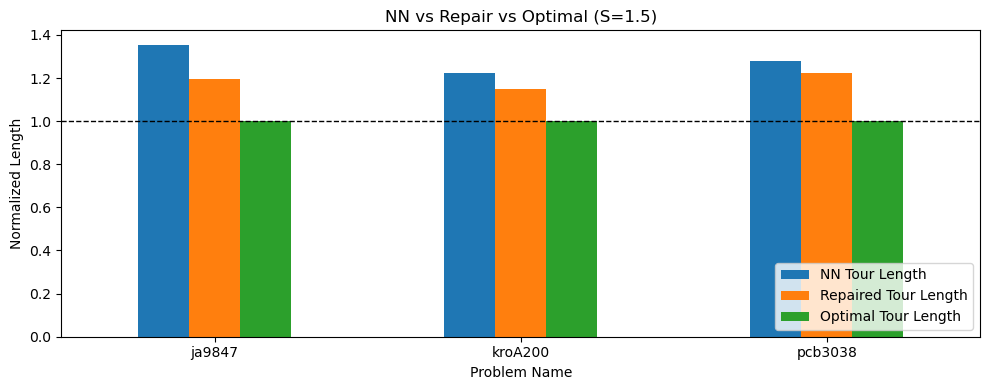

In [18]:
# drop those with no bad pairs
bad_count_df = df[df.bad_pair_count > 0].copy()

pct_df = bad_count_df[["nn_len", "repair_len", "opt_len"]].div(bad_count_df["opt_len"], axis=0)

ax = pct_df.rename(columns=human_readable_names).plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_xlabel("Problem Name")
ax.set_ylabel("Normalized Length")
ax.set_title("NN vs Repair vs Optimal (S=1.5)")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)

ax.figure.tight_layout()
ax.legend(loc="lower right")